# 05 — EXPLORATORY: does per-start velocity track per-start results?

**Not pre-registered.** Designed on 2026-10-01 after Sections 1–3 results were seen, to check the owner's
candidate dominant explanation ("velocity drives his quality"). The writeup must label it exploratory.

Unit = start. Sasaki: 31 starts (2025–26). Benchmark: Yamamoto, 85 starts (2024–26). 2026 postseason excluded.
Predictor: per-start average FF velocity, both raw and season-centered (velo minus that season's mean).
Season-centering separates "velocity on the day" from season-level changes (2026 mechanics/arsenal).
Outcomes: xwOBA allowed, runs charged per batter faced, splitter whiff per swing (FO + FS combined),
bad start (3+ R). Method: OLS slope per 1 mph and Pearson r, 95% bootstrap CIs over starts (10,000 reps).
No pass/fail thresholds.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path("../data/raw")
FIG = Path("../figures")
B = 10_000
rng = np.random.default_rng(5)

# Robustness switch: H1_VARIANT=no_tokyo drops Sasaki's 2025-03-19 / 03-29 starts. Variants write suffixed outputs, no figures.
VARIANT = os.environ.get("H1_VARIANT", "baseline")
SUFFIX = "" if VARIANT == "baseline" else f"_{VARIANT}"
WHIFF = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
SWING = WHIFF | {"foul", "foul_tip", "foul_bunt", "bunt_foul_tip", "hit_into_play"}

In [2]:
def starts(name, seasons):
    d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
                   for y in seasons], ignore_index=True)
    d = d[(d.game_type != "S") & ~((d.season == 2026) & d.game_type.isin(["F", "D", "L", "W"]))]
    d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
    d = d[~d.pa_id.isin(d.loc[d.events == "intent_walk", "pa_id"])]
    d = d[d.groupby("game_pk").inning.transform("min") == 1]
    pa = d[d.events.notna()].copy()
    pa["xw"] = np.where(pa.estimated_woba_using_speedangle.notna(), pa.estimated_woba_using_speedangle, pa.woba_value)
    spl = d[d.pitch_type.isin(["FO", "FS"])]
    g = pd.DataFrame({
        "season": d.groupby("game_pk").season.first(),
        "ff_velo": d[d.pitch_type == "FF"].groupby("game_pk").release_speed.mean(),
        "xw_num": pa.groupby("game_pk").xw.sum(),
        "xw_den": pa.groupby("game_pk").woba_denom.sum(),
        "spl_whiffs": spl[spl.description.isin(WHIFF)].groupby("game_pk").size(),
        "spl_swings": spl[spl.description.isin(SWING)].groupby("game_pk").size(),
    }).fillna({"spl_whiffs": 0, "spl_swings": 0})
    logs = pd.read_csv(RAW / f"{name}_game_logs.csv").set_index("game_pk")
    g = g.join(logs[["runs", "battersFaced", "date"]], how="inner")
    g["xwoba"] = g.xw_num / g.xw_den
    g["runs_per_bf"] = g.runs / g.battersFaced
    g["spl_whiff"] = 100 * g.spl_whiffs / g.spl_swings.replace(0, np.nan)
    g["bad"] = (g.runs >= 3).astype(float)
    g["velo_c"] = g.ff_velo - g.groupby("season").ff_velo.transform("mean")
    g["pitcher_name"] = name
    return g.reset_index()

S = pd.concat([starts("sasaki", [2025, 2026]), starts("yamamoto", [2024, 2025, 2026])], ignore_index=True)
if VARIANT == "no_tokyo":
    S = S[~S.game_pk.isin([778564, 778533])]
S.groupby(["pitcher_name", "season"]).agg(starts=("game_pk", "size"), ff_velo=("ff_velo", "mean"), xwoba=("xwoba", "mean")).round(3)

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15986/1193953351.py

starts  ff_velo  xwoba
pitcher_name season                        
sasaki       2025         8   95.982  0.367
             2026        23   97.843  0.326
yamamoto     2024        22   95.476  0.298
             2025        35   95.484  0.269
             2026        28   96.066  0.267

## Slope per 1 mph and correlation

In [3]:
def fit(x, y):
    ok = ~(np.isnan(x) | np.isnan(y))
    x, y = x[ok], y[ok]
    slope, r = np.polyfit(x, y, 1)[0], np.corrcoef(x, y)[0, 1]
    idx = rng.integers(0, len(x), size=(B, len(x)))
    bs = np.array([np.polyfit(x[i], y[i], 1)[0] for i in idx])
    br = np.array([np.corrcoef(x[i], y[i])[0, 1] for i in idx])
    return len(x), slope, np.nanpercentile(bs, [2.5, 97.5]), r, np.nanpercentile(br, [2.5, 97.5])

rows = []
for name in ["sasaki", "yamamoto"]:
    d = S[S.pitcher_name == name]
    for pred in ["ff_velo", "velo_c"]:
        for out, digits in [("xwoba", 3), ("runs_per_bf", 3), ("spl_whiff", 1), ("bad", 3)]:
            n, slope, sci, r, rci = fit(d[pred].values, d[out].values)
            rows.append({"pitcher": name, "predictor": "raw FF velo" if pred == "ff_velo" else "season-centered velo",
                         "outcome": out, "starts": n, "slope per mph": round(slope, digits),
                         "slope CI": f"[{sci[0]:.{digits}f}, {sci[1]:.{digits}f}]",
                         "r": round(r, 2), "r CI": f"[{rci[0]:.2f}, {rci[1]:.2f}]"})
expl = pd.DataFrame(rows)
expl.to_csv(f"../data/processed/s5_velocity_exploratory{SUFFIX}.csv", index=False)
expl

,pitcher,predictor,outcome,starts,slope per mph,slope CI,r,r CI
0,sasaki,raw FF velo,xwoba,31,-0.031,"[-0.048, -0.017]",-0.54,"[-0.72, -0.31]"
1,sasaki,raw FF velo,runs_per_bf,31,-0.012,"[-0.032, 0.010]",-0.19,"[-0.54, 0.15]"
2,sasaki,raw FF velo,spl_whiff,31,1.900,"[-2.2, 6.0]",0.17,"[-0.20, 0.49]"
3,sasaki,raw FF velo,bad,31,-0.092,"[-0.222, 0.054]",-0.23,"[-0.54, 0.13]"
4,sasaki,season-centered velo,xwoba,31,-0.038,"[-0.065, -0.017]",-0.49,"[-0.70, -0.24]"
5,sasaki,season-centered velo,runs_per_bf,31,-0.024,"[-0.049, 0.003]",-0.30,"[-0.60, 0.03]"
6,sasaki,season-centered velo,spl_whiff,31,4.200,"[-0.2, 8.9]",0.28,"[-0.01, 0.53]"
7,sasaki,season-centered velo,bad,31,-0.213,"[-0.366, -0.055]",-0.41,"[-0.69, -0.10]"
8,yamamoto,raw FF velo,xwoba,85,-0.022,"[-0.047, 0.002]",-0.19,"[-0.37, 0.02]"
9,yamamoto,raw FF velo,runs_per_bf,85,-0.032,"[-0.063, -0.006]",-0.21,"[-0.37, -0.05]"


## Velocity terciles (Sasaki, raw velo): pooled outcomes

In [4]:
d = S[S.pitcher_name == "sasaki"].copy()
d["velo_tercile"] = pd.qcut(d.ff_velo, 3, labels=["Low", "Mid", "High"])
d.groupby("velo_tercile", observed=True).agg(starts=("game_pk", "size"), velo_range=("ff_velo", lambda v: f"{v.min():.1f}–{v.max():.1f}"),
                                             xwoba=("xw_num", "sum"), den=("xw_den", "sum"), runs=("runs", "sum"),
                                             bf=("battersFaced", "sum"), bad_starts=("bad", "sum")).assign(
    xwoba=lambda t: (t.xwoba / t.den).round(3), runs_per_bf=lambda t: (t.runs / t.bf).round(3)).drop(columns=["den"])

,starts,velo_range,xwoba,runs,bf,bad_starts,runs_per_bf
velo_tercile,,,,,,,
Low,11,94.7–96.9,0.361,29,235,5.0,0.123
Mid,10,97.0–98.0,0.385,30,202,7.0,0.149
High,10,98.1–100.1,0.263,22,228,3.0,0.096


## Figure — per-start velocity vs. xwOBA

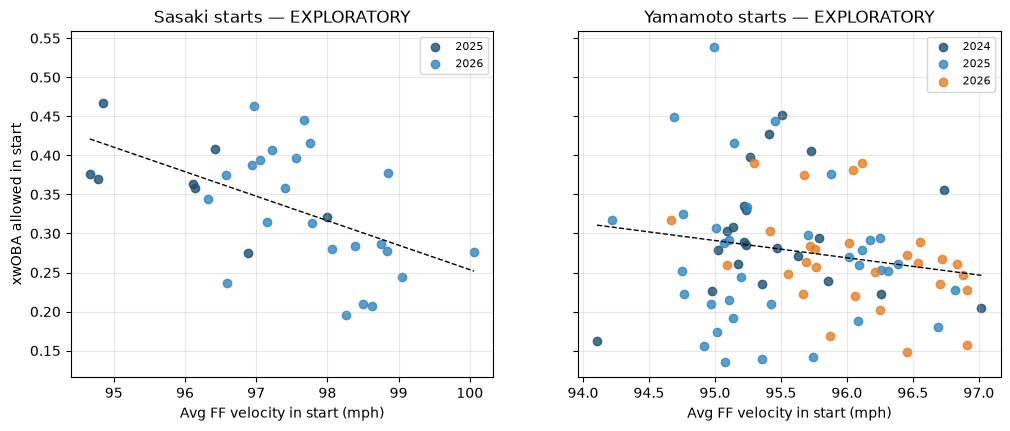

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name in zip(axes, ["sasaki", "yamamoto"]):
    d = S[S.pitcher_name == name]
    for season, color in zip(sorted(d.season.unique()), ["#1b4f72", "#2e86c1", "#e67e22"]):
        s = d[d.season == season]
        ax.scatter(s.ff_velo, s.xwoba, color=color, label=str(season), alpha=0.8)
    coef = np.polyfit(d.ff_velo, d.xwoba, 1)
    xs = np.linspace(d.ff_velo.min(), d.ff_velo.max(), 10)
    ax.plot(xs, np.polyval(coef, xs), color="black", ls="--", lw=1)
    ax.set_title(f"{name.title()} starts — EXPLORATORY")
    ax.set_xlabel("Avg FF velocity in start (mph)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("xwOBA allowed in start")
if VARIANT == "baseline":
    fig.savefig(FIG / "s5_velocity_vs_xwoba.png", dpi=150, bbox_inches="tight")

## Follow-up (EXPLORATORY): FS-era starts only

Added 2026-10-01. In the tercile table, every high-velocity start came from 2026 and 97% of their splitters were the new FS, so velocity and the new splitter were bundled together.
This restricts to starts from **2026-04-25 onward** (the first start with the new FS; 19 starts) so the splitter is held constant.
Velocity also rose across the season, so a second version removes the linear time trend (start order) from both velocity and the outcome (a partial correlation).

In [6]:
fs = S[(S.pitcher_name == "sasaki") & (pd.to_datetime(S.date) >= "2026-04-25")].copy()
fs["order"] = pd.to_datetime(fs.date).rank()

def resid(y, x):
    return y - np.polyval(np.polyfit(x, y, 1), x)

rows = []
for out, digits in [("xwoba", 3), ("runs_per_bf", 3), ("spl_whiff", 1), ("bad", 3)]:
    n, slope, sci, r, rci = fit(fs.ff_velo.values, fs[out].values)
    rows.append({"version": "raw", "outcome": out, "starts": n, "slope per mph": round(slope, digits),
                 "slope CI": f"[{sci[0]:.{digits}f}, {sci[1]:.{digits}f}]", "r": round(r, 2), "r CI": f"[{rci[0]:.2f}, {rci[1]:.2f}]"})
    ok = fs[out].notna()
    xv, yv = resid(fs.ff_velo[ok].values, fs.order[ok].values), resid(fs[out][ok].values, fs.order[ok].values)
    n, slope, sci, r, rci = fit(xv, yv)
    rows.append({"version": "time trend removed", "outcome": out, "starts": n, "slope per mph": round(slope, digits),
                 "slope CI": f"[{sci[0]:.{digits}f}, {sci[1]:.{digits}f}]", "r": round(r, 2), "r CI": f"[{rci[0]:.2f}, {rci[1]:.2f}]"})
fs_era = pd.DataFrame(rows)
fs_era.to_csv(f"../data/processed/s5_fs_era{SUFFIX}.csv", index=False)
print("FS-era FF velo range:", round(fs.ff_velo.min(), 1), "-", round(fs.ff_velo.max(), 1))
fs_era

FS-era FF velo range: 96.3 - 100.1


,version,outcome,starts,slope per mph,slope CI,r,r CI
0,raw,xwoba,19,-0.038,"[-0.086, -0.008]",-0.43,"[-0.73, -0.10]"
1,time trend removed,xwoba,19,-0.048,"[-0.090, -0.013]",-0.49,"[-0.77, -0.13]"
2,raw,runs_per_bf,19,-0.016,"[-0.054, 0.027]",-0.18,"[-0.59, 0.25]"
3,time trend removed,runs_per_bf,19,-0.019,"[-0.059, 0.037]",-0.18,"[-0.64, 0.31]"
4,raw,spl_whiff,19,3.400,"[-2.2, 10.2]",0.22,"[-0.16, 0.52]"
5,time trend removed,spl_whiff,19,3.100,"[-1.5, 10.0]",0.19,"[-0.09, 0.45]"
6,raw,bad,19,-0.220,"[-0.443, 0.015]",-0.41,"[-0.74, 0.03]"
7,time trend removed,bad,19,-0.161,"[-0.398, 0.147]",-0.29,"[-0.70, 0.23]"


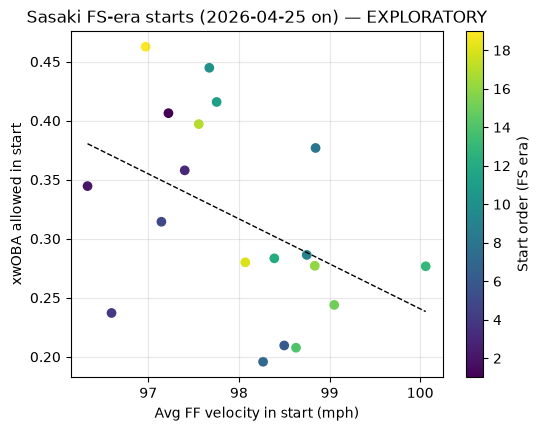

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sc = ax.scatter(fs.ff_velo, fs.xwoba, c=fs.order, cmap="viridis")
coef = np.polyfit(fs.ff_velo, fs.xwoba, 1)
xs = np.linspace(fs.ff_velo.min(), fs.ff_velo.max(), 10)
ax.plot(xs, np.polyval(coef, xs), color="black", ls="--", lw=1)
fig.colorbar(sc, label="Start order (FS era)")
ax.set_xlabel("Avg FF velocity in start (mph)")
ax.set_ylabel("xwOBA allowed in start")
ax.set_title("Sasaki FS-era starts (2026-04-25 on) — EXPLORATORY")
ax.grid(alpha=0.3)
if VARIANT == "baseline":
    fig.savefig(FIG / "s5_fs_era.png", dpi=150, bbox_inches="tight")